### Equipe:

- Allanis Beatriz Oliveira Maia de Lima - aboml@cin.ufpe.br
- Amanda Pereira Muniz de Oliveira - apmo@cin.ufpe.br
- João Victor Alexandre Justino da Silva - jvajs@cin.ufpe.br
- Millena Ferreira Marçal das Neves - mfmn@cin.ufpe.br
- Nelson de Barros Sales Neto - nbsn@cin.ufpe.br


## Projeto da disciplina ciência de dados

O projeto tem como objetivo o desenvolvimento de um modelo preditivo utilizando o algoritmo k-Nearest Neighbors (kNN), com foco na previsão da gravidade de ocorrências de trânsito. Para isso, foi selecionado o dataset "Ocorrências de Acidentes de Trânsito - 2024", disponibilizado pela Prefeitura do Recife.
A escolha desse conjunto de dados se justifica pela sua riqueza de informações, contemplando diferentes aspectos relacionados aos acidentes, como localização geográfica, características da via, tipos de veículos envolvidos e número de vítimas. Esses fatores são relevantes para a construção de um modelo capaz de identificar padrões e auxiliar na previsão da gravidade dos acidentes.



**Importação**



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/MillenaNeves/Ciencia-de-dados/main/acidentes_recife_2024%20(1).csv', sep=';', encoding='utf-8', decimal=',')

**Limpeza dos dados**

In [ ]:
colunas_remover = ['situacao_semaforo', 'tempo_clima', 'acidente_verificado', 'mao_direcao',
                   'conservacao_via', 'ponto_controle', 'velocidade_max_via', 'divisao_via2',
                   'divisao_via1', 'num_semaforo', 'condicao_via', 'sinalizacao', 'situacao_placa',
                   'Protocolo', 'endereco', 'numero', 'detalhe_endereco_acidente', 'complemento',
                   'bairro_cruzamento', 'data'] # 'hora' foi removida desta lista
df.drop(columns=colunas_remover, errors='ignore', inplace=True)

# limpeza da variável alvo e preenchimento de nulos nas features categóricas
df.dropna(subset=['natureza'], inplace=True)
df = df[~df['natureza'].isin(['APOIO', 'ENTRADA E SAÍDA'])]

cat_cols = [c for c in df.columns if df[c].dtype == 'object' and c != 'natureza']
df[cat_cols] = df[cat_cols].fillna('N/A')

# tratamento de outliers nas variáveis numéricas utilizando o método IQR
num_cols = ['auto', 'moto', 'ciclom', 'ciclista', 'pedestre', 'onibus', 'caminhao', 'vitimas']
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    df[col] = df[col].clip(lower=q1 - 1.5*iqr, upper=q3 + 1.5*iqr)


# Entrega 5

**DIVISÃO INICIAL DE DADOS (TESTE ISOLADO E INTOCÁVEL**

In [ ]:
# separando as variáveis preditoras e o alvo (natureza)
X = df.drop(columns=['natureza'])
y = df['natureza']

# divisão 70% Treino e 30% Teste utilizando stratify para manter a proporção das classes
X_train_bruto, X_test_bruto, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# identificando colunas numéricas e categóricas para o pré-processamento
colunas_numericas = X_train_bruto.select_dtypes(include=[np.number]).columns.tolist()
colunas_categoricas = X_train_bruto.select_dtypes(exclude=[np.number]).columns.tolist()

**AVALIAÇÃO DO BASELINE (MELHOR MODELO DA ENTREGA 4)**

In [ ]:
# Imputação Simples, OneHotEncoder, Sem PCA, Balanceamento por SMOTE e kNN, (k=5
print("Calculando as métricas do Baseline (Melhor Modelo até a Entrega 4) via Validação Cruzada...")

transformador_baseline = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')), # estratégia padrão adotada
        ('scaler', StandardScaler())
    ]), colunas_numericas),
    ('cat', Pipeline([
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]), colunas_categoricas)
])

pipeline_baseline = ImbPipeline([
    ('pre_processamento', transformador_baseline),
    ('balanceamento_classes', SMOTE(random_state=42)), # melhor técnica da Entrega 4
    ('classificador_knn', KNeighborsClassifier(n_neighbors=5, metric='euclidean'))
])

cv_baseline = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_baseline = cross_validate(
    pipeline_baseline, X_train_bruto, y_train,
    cv=cv_baseline,
    scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
    n_jobs=-1
)

print("\n=======================================================")
print("      MÉTRICAS DO BASELINE INICIAL (ENTREGA 4)         ")
print("=======================================================")
print(f"Acurácia Média (CV): {np.mean(scores_baseline['test_accuracy']):.4f}")
print(f"F1-Score Macro Médio (CV): {np.mean(scores_baseline['test_f1_macro']):.4f}")
print("=======================================================\n")

Calculando as métricas do Baseline (Melhor Modelo até a Entrega 4) via Validação Cruzada...

      MÉTRICAS DO BASELINE INICIAL (ENTREGA 4)         
Acurácia Média (CV): 0.6207
F1-Score Macro Médio (CV): 0.6915



**DEFINIÇÃO DAS OPÇÕES DE PRÉ-PROCESSAMENTO (MÍNIMO 100 CENÁRIOS)**

In [ ]:
opcoes_imputer = {
    'media': SimpleImputer(strategy='mean'),
    'mediana': SimpleImputer(strategy='median'),
    'frequente': SimpleImputer(strategy='most_frequent')
}

opcoes_encoder = {
    'OneHot': OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
    'Ordinal': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
    'Target': TargetEncoder(random_state=42)
}

opcoes_selecao = {
    'KBest_5': SelectKBest(score_func=f_classif, k=5),
    'KBest_10': SelectKBest(score_func=f_classif, k=10),
    'KBest_15': SelectKBest(score_func=f_classif, k=15),
    'KBest_20': SelectKBest(score_func=f_classif, k=20)
}

opcoes_pca = {
    'Sem_PCA': 'passthrough',
    'PCA_3': PCA(n_components=3, random_state=42),
    'PCA_5': PCA(n_components=5, random_state=42)
}

opcoes_balanceamento = {
    'Sem_Balanceamento': 'passthrough',
    'SMOTE': SMOTE(random_state=42),
    'Undersampling': RandomUnderSampler(random_state=42)
}

opcoes_distancia = ['euclidean', 'manhattan']

# lista para armazenar o dicionário com os resultados de cada combinação
resultados_lista = []

# gerando todas as combinações possíveis de pré-processamento
combinacoes = list(product(
    opcoes_imputer.keys(),
    opcoes_encoder.keys(),
    opcoes_selecao.keys(),
    opcoes_pca.keys(),
    opcoes_balanceamento.keys(),
    opcoes_distancia
))

print(f"Total de combinações geradas para teste sistemático: {len(combinacoes)} cenários.")

Total de combinações geradas para teste sistemático: 648 cenários.


**EXECUÇÃO DA AUTOMAÇÃO COM VALIDAÇÃO CRUZADA**

In [ ]:
cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for imp_nome, enc_nome, sel_nome, pca_nome, bal_nome, dist in combinacoes:

    # Construção do ColumnTransformer para tratar dados numéricos e categóricos adequadamente
    transformador_colunas = ColumnTransformer(transformers=[
        ('num', Pipeline([
            ('imputer', opcoes_imputer[imp_nome]),
            ('scaler', StandardScaler())
        ]), colunas_numericas),
        ('cat', Pipeline([
            ('encoder', opcoes_encoder[enc_nome])
        ]), colunas_categoricas)
    ])

    # Definição do Pipeline utilizando imblearn para suportar o balanceamento de classes com segurança
    pipeline_experimento = ImbPipeline([
        ('pre_processamento', transformador_colunas),
        ('selecao_features', opcoes_selecao[sel_nome]),
        ('reducao_dim', opcoes_pca[pca_nome]),
        ('balanceamento_classes', opcoes_balanceamento[bal_nome]),
        ('classificador_knn', KNeighborsClassifier(n_neighbors=5, metric=dist)) # k=5 Fixo exigido
    ])

    # Executando a validação cruzada de forma justa apenas na base de treino
    scores = cross_validate(
        pipeline_experimento, X_train_bruto, y_train,
        cv=cv_estrategia,
        scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
        n_jobs=-1
    )

    # Computando as médias obtidas nos 5 folds da validação cruzada
    acc_media = np.mean(scores['test_accuracy'])
    f1_medio = np.mean(scores['test_f1_macro'])

    # Armazenando os metadados e resultados do cenário avaliado
    resultados_lista.append({
        'Imputação': imp_nome,
        'Encoding': enc_nome,
        'Seleção (K)': sel_nome,
        'PCA': pca_nome,
        'Balanceamento': bal_nome,
        'Distância KNN': dist,
        'Acurácia (CV)': acc_media,
        'F1-Score Macro (CV)': f1_medio
    })

# Convertendo os resultados consolidados para um DataFrame do pandas
df_resultados_experimentos = pd.DataFrame(resultados_lista)
print("Automação concluída com sucesso!")

Automação concluída com sucesso!


**IDENTIFICAÇÃO DO MELHOR E PIOR CENÁRIO (TABELA COMPARATIVA)**

In [ ]:
df_resultados_ordenados = df_resultados_experimentos.sort_values(by='F1-Score Macro (CV)', ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', None)
df_resultados_ordenados

,Imputação,Encoding,Seleção (K),PCA,Balanceamento,Distância KNN,Acurácia (CV),F1-Score Macro (CV)
0,media,Target,KBest_20,PCA_3,Sem_Balanceamento,euclidean,0.928763,0.870319
1,mediana,Target,KBest_20,PCA_3,Sem_Balanceamento,euclidean,0.928763,0.870319
2,frequente,Target,KBest_20,PCA_3,Sem_Balanceamento,euclidean,0.928763,0.870319
3,mediana,Target,KBest_20,PCA_3,Sem_Balanceamento,manhattan,0.925806,0.866228
4,frequente,Target,KBest_20,PCA_3,Sem_Balanceamento,manhattan,0.925806,0.866228
5,media,Target,KBest_20,PCA_3,Sem_Balanceamento,manhattan,0.925806,0.866228
6,mediana,Target,KBest_20,Sem_PCA,Sem_Balanceamento,euclidean,0.924194,0.861375
7,media,Target,KBest_20,Sem_PCA,Sem_Balanceamento,euclidean,0.924194,0.861375
8,frequente,Target,KBest_20,Sem_PCA,Sem_Balanceamento,euclidean,0.924194,0.861375
9,media,Target,KBest_20,Sem_PCA,Sem_Balanceamento,manhattan,0.922043,0.858406


In [ ]:
print("\n TOP 5 MELHORES COMBINAÇÕES DE PRÉ-PROCESSAMENTO (baseado em F1-Macro)")
display(df_resultados_ordenados.head(5))

print("\n PIOR COMBINAÇÃO DE PRÉ-PROCESSAMENTO REGISTRADA")
display(df_resultados_ordenados.tail(1))


 TOP 5 MELHORES COMBINAÇÕES DE PRÉ-PROCESSAMENTO (baseado em F1-Macro)


,Imputação,Encoding,Seleção (K),PCA,Balanceamento,Distância KNN,Acurácia (CV),F1-Score Macro (CV)
0,media,Target,KBest_20,PCA_3,Sem_Balanceamento,euclidean,0.928763,0.870319
1,mediana,Target,KBest_20,PCA_3,Sem_Balanceamento,euclidean,0.928763,0.870319
2,frequente,Target,KBest_20,PCA_3,Sem_Balanceamento,euclidean,0.928763,0.870319
3,mediana,Target,KBest_20,PCA_3,Sem_Balanceamento,manhattan,0.925806,0.866228
4,frequente,Target,KBest_20,PCA_3,Sem_Balanceamento,manhattan,0.925806,0.866228



 PIOR COMBINAÇÃO DE PRÉ-PROCESSAMENTO REGISTRADA


,Imputação,Encoding,Seleção (K),PCA,Balanceamento,Distância KNN,Acurácia (CV),F1-Score Macro (CV)
647,media,Ordinal,KBest_10,PCA_3,Undersampling,manhattan,0.54328,0.299037


**TREINAMENTO FINAL E AVALIAÇÃO CONTRA O TESTE ISOLADO**

In [ ]:
# Extraindo a configuração vencedora
melhor_cenario = df_resultados_ordenados.iloc[0]

print(f"\nConfiguração Campeã Selecionada:\n{melhor_cenario.to_dict()}")

# Reconstruindo o pipeline ideal definitivo utilizando os hiperparâmetros campeões
melhor_transformador = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', opcoes_imputer[melhor_cenario['Imputação']]),
        ('scaler', StandardScaler())
    ]), colunas_numericas),
    ('cat', Pipeline([
        ('encoder', opcoes_encoder[melhor_cenario['Encoding']])
    ]), colunas_categoricas)
])

pipeline_campeao_definitivo = ImbPipeline([
    ('pre_processamento', melhor_transformador),
    ('selecao_features', opcoes_selecao[melhor_cenario['Seleção (K)']]),
    ('reducao_dim', opcoes_pca[melhor_cenario['PCA']]),
    ('balanceamento_classes', opcoes_balanceamento[melhor_cenario['Balanceamento']]),
    ('classificador_knn', KNeighborsClassifier(n_neighbors=5, metric=melhor_cenario['Distância KNN']))
])
# Treinando o modelo final com 100% dos dados do conjunto de treino
pipeline_campeao_definitivo.fit(X_train_bruto, y_train)

# Fazendo a predição final contra o conjunto de teste que ficou totalmente isolado e intocável
y_pred_final = pipeline_campeao_definitivo.predict(X_test_bruto)
y_prob_final = pipeline_campeao_definitivo.predict_proba(X_test_bruto)


Configuração Campeã Selecionada:
{'Imputação': 'media', 'Encoding': 'Target', 'Seleção (K)': 'KBest_20', 'PCA': 'PCA_3', 'Balanceamento': 'Sem_Balanceamento', 'Distância KNN': 'euclidean', 'Acurácia (CV)': 0.928763440860215, 'F1-Score Macro (CV)': 0.8703194733527772}


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [1 2 3 4 5 6 9] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


**EXIBIÇÃO DAS MÉTRICAS DO MODELO CAMPEÃO NO TESTE**

In [ ]:
acc_final = accuracy_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final, average='macro')
auc_final = roc_auc_score(y_test, y_prob_final, multi_class='ovr')

print("\n=======================================================")
print("     AVALIAÇÃO FINAL DO PIPELINE IDEAL NO TESTE        ")
print("=======================================================")
print(f"Acurácia no Teste: {acc_final:.4f}")
print(f"F1-Score Macro no Teste: {f1_final:.4f}")
print(f"AUC Global (One-vs-Rest) no Teste: {auc_final:.4f}\n")

print("Relatório de Classificação Final (Classification Report):")
print(classification_report(y_test, y_pred_final))


     AVALIAÇÃO FINAL DO PIPELINE IDEAL NO TESTE        
Acurácia no Teste: 0.9260
F1-Score Macro no Teste: 0.8602
AUC Global (One-vs-Rest) no Teste: 0.9029

Relatório de Classificação Final (Classification Report):
              precision    recall  f1-score   support

  COM VÍTIMA       0.94      0.98      0.96      1402
  SEM VÍTIMA       0.75      0.53      0.62       183
VÍTIMA FATAL       1.00      1.00      1.00        10

    accuracy                           0.93      1595
   macro avg       0.90      0.84      0.86      1595
weighted avg       0.92      0.93      0.92      1595



Matriz de Confusão Final:


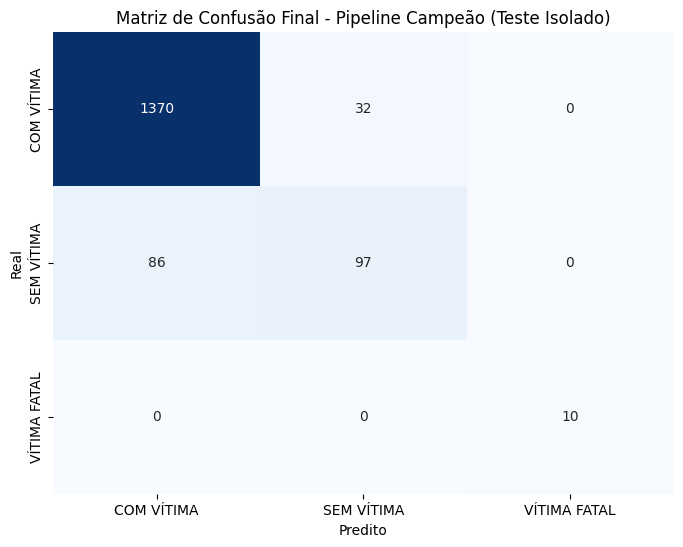

In [ ]:
# Exibição estruturada da Matriz de Confusão Final
print("Matriz de Confusão Final:")
matriz_conf = confusion_matrix(y_test, y_pred_final)
df_cm = pd.DataFrame(matriz_conf, index=pipeline_campeao_definitivo.classes_, columns=pipeline_campeao_definitivo.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão Final - Pipeline Campeão (Teste Isolado)')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.show()

**Gerando Tabela Resumo Comparativa da Validação Cruzada vs Teste para o relatório**

In [ ]:
tabela_final = pd.DataFrame({
    'Métrica': ['Acurácia', 'F1-Score Macro', 'AUC Global (OvR)'],
    'Validação Cruzada (média 5 folds)': [melhor_cenario['Acurácia (CV)'], melhor_cenario['F1-Score Macro (CV)'], '—'],
    'Avaliação Final (teste isolado)': [acc_final, f1_final, auc_final]
})
display(tabela_final)

,Métrica,Validação Cruzada (média 5 folds),Avaliação Final (teste isolado)
0,Acurácia,0.928763,0.926019
1,F1-Score Macro,0.870319,0.860169
2,AUC Global (OvR),—,0.902867
